In [82]:
import pandas as pd
df_md4 = pd.read_csv('microbench-md4-cube-0.csv')
df_md42 = pd.read_csv('microbench-md4-m2-0.csv')

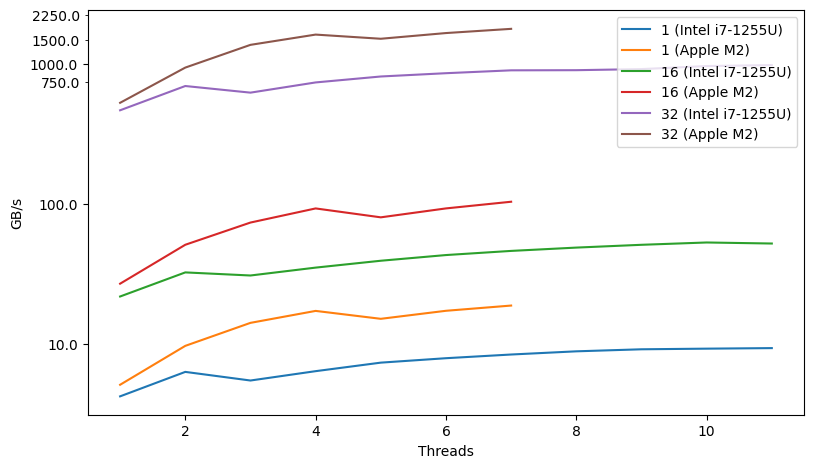

In [84]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator, LogLocator
import numpy as np

for matches in [1, 16, 32]:
    base = df_md4[(df_md4['simd_mode'] == 'avx2') & (df_md4['matches'] == matches)]
    plt.plot(base['thread_count'], base['avg_thr_bytes'] / 1073741824, label='{} (Intel i7-1255U)'.format(matches), lw=1.5)
    base = df_md42[(df_md42['simd_mode'] == 'neon') & (df_md42['matches'] == matches)]
    plt.plot(base['thread_count'], base['avg_thr_bytes'] / 1073741824, label='{} (Apple M2)'.format(matches), lw=1.5)
plt.yscale('log')
plt.ylabel('GB/s')
plt.xlabel('Threads')


sf = FormatStrFormatter('%.1f')

ax = plt.gca()
ax.yaxis.set_major_formatter(sf)
ax.yaxis.set_minor_formatter(sf)
ax.yaxis.set_major_locator(LogLocator(numticks=20))
ax.yaxis.set_minor_locator(MultipleLocator(750))
plt.legend(loc='upper right')

fig = plt.gcf()
fig.set_size_inches(9.25, 5.25)
fig.set_dpi(100)

In [74]:
import pandas as pd
df_phf = pd.read_csv('microbench-phf-cube-0.csv')
df_phf['avg_thr_elem_s'] = df_phf['avg_thr_melem_s'] * 1000000
df_phf['min_thr_elem_s'] = df_phf['min_thr_melem_s'] * 1000000
df_phf['max_thr_elem_s'] = df_phf['max_thr_melem_s'] * 1000000
df_phf2 = pd.read_csv('microbench-phf-m2-0.csv')
df_phf2['avg_thr_elem_s'] = df_phf2['avg_thr_melem_s'] * 1000000
df_phf2['min_thr_elem_s'] = df_phf2['min_thr_melem_s'] * 1000000
df_phf2['max_thr_elem_s'] = df_phf2['max_thr_melem_s'] * 1000000

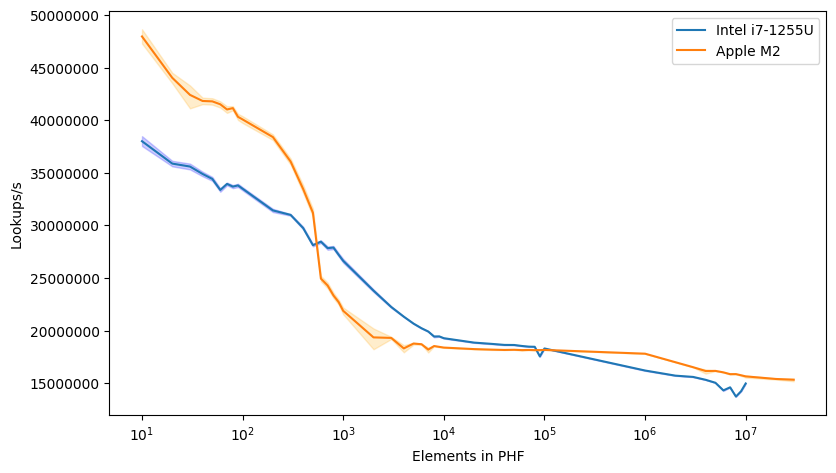

In [79]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator, LogLocator
import numpy as np

plt.plot(df_phf['size'], df_phf['avg_thr_elem_s'], lw=1.5, label='Intel i7-1255U')
plt.fill_between(df_phf['size'], df_phf['min_thr_elem_s'], df_phf['max_thr_elem_s'], color = 'blue', alpha = 0.2)
plt.plot(df_phf2['size'], df_phf2['avg_thr_elem_s'], lw=1.5, label='Apple M2')
plt.fill_between(df_phf2['size'], df_phf2['min_thr_elem_s'], df_phf2['max_thr_elem_s'], color = 'orange', alpha = 0.2)
plt.ylabel('Lookups/s')
plt.xlabel('Elements in PHF')
plt.xscale('symlog')
plt.yscale('linear')
plt.legend()
ax = plt.gca()
ax.ticklabel_format(axis='y', style='plain')

fig = plt.gcf()
fig.set_size_inches(9.25, 5.25)
fig.set_dpi(100)